# ***Importing Dataset***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -o -q "/content/drive/MyDrive/cleaned_dataset.zip" -d /content/
print("done.")

Mounted at /content/drive
done.


In [ ]:
import os, glob
if os.path.exists("/content/cleaned_dataset.zip"):
    zip_path = "/content/cleaned_dataset.zip"
else:
    drive_zips = glob.glob("/content/drive/MyDrive/**/cleaned_dataset*.zip", recursive=True)
    if drive_zips:
        zip_path = drive_zips[0]
    else:
        raise FileNotFoundError("Zip file Not found")

print(f"Using zip: {zip_path}")
!unzip -o -q "{zip_path}" -d /content/

Using zip: /content/drive/MyDrive/cleaned_dataset.zip


In [ ]:
import os, glob, re, numpy as np, pandas as pd

if 'df_meta' not in globals():
    meta_files = [os.path.join(r, f) for r, d, fs in os.walk('/content') for f in fs if f == 'metadata.csv' and 'drive' not in r]
    if not meta_files:
        drive_zips = glob.glob('/content/drive/MyDrive/**/cleaned_dataset*.zip', recursive=True)
        if drive_zips:
            !unzip -o -q "{drive_zips[0]}" -d /content/
        meta_files = [os.path.join(r, f) for r, d, fs in os.walk('/content') for f in fs if f == 'metadata.csv' and 'drive' not in r]

    METADATA_PATH = meta_files[0]
    df_meta = pd.read_csv(METADATA_PATH)

    def sanitize_cap(x):
        if pd.isna(x) or str(x).strip() in ['[]', '']:
            return np.nan
        try:
            v = float(x)
            return v if v > 0.05 else np.nan
        except:
            return np.nan

    df_meta['clean_capacity'] = df_meta['Capacity'].apply(sanitize_cap)

def generate_quality_table(df):
    records = []
    for b_id, grp in df.groupby('battery_id'):
        dis_grp = grp[grp['type'] == 'discharge']
        chg_grp = grp[grp['type'] == 'charge']
        imp_grp = grp[grp['type'] == 'impedance']
        valid_caps = dis_grp['clean_capacity'].dropna()
        temps = '/'.join(map(str, sorted(grp['ambient_temperature'].unique())))
        missing_count = len(dis_grp) - len(valid_caps)
        min_c = f"{valid_caps.min():.3f}" if len(valid_caps) > 0 else "N/A"
        max_c = f"{valid_caps.max():.3f}" if len(valid_caps) > 0 else "N/A"

        issues = []
        if missing_count > 0: issues.append(f"{missing_count} missing/aborted")
        if len(valid_caps) > 0 and valid_caps.max() > 2.2: issues.append("Cap > 2.2Ah spike")
        if len(valid_caps) > 0 and valid_caps.min() < 0.2: issues.append("Deep EOL (<0.2Ah)")

        records.append({
            'Battery_ID': b_id,
            'Ambient_Temp_C': temps,
            'Total_Cycles': len(grp),
            'Discharge_Count': len(dis_grp),
            'Charge_Count': len(chg_grp),
            'Impedance_Count': len(imp_grp),
            'Valid_Capacity_Cycles': len(valid_caps),
            'Missing_Cap_Count': missing_count,
            'Min_Capacity_Ah': min_c,
            'Max_Capacity_Ah': max_c,
            'Data_Quality_Notes': ', '.join(issues) if issues else 'Clean'
        })
    return pd.DataFrame(records)

df_quality = generate_quality_table(df_meta)
df_quality.to_csv('/content/battery_data_quality_report.csv', index=False)
display(df_quality)

,Battery_ID,Ambient_Temp_C,Total_Cycles,Discharge_Count,Charge_Count,Impedance_Count,Valid_Capacity_Cycles,Missing_Cap_Count,Min_Capacity_Ah,Max_Capacity_Ah,Data_Quality_Notes
0,B0005,24,616,168,170,278,168,0,1.287,1.856,Clean
1,B0006,24,616,168,170,278,168,0,1.154,2.035,Clean
2,B0007,24,616,168,170,278,168,0,1.400,1.891,Clean
3,B0018,24,319,132,134,53,132,0,1.341,1.855,Clean
4,B0025,24,80,28,31,21,28,0,1.768,1.849,Clean
5,B0026,24,80,28,31,21,28,0,1.386,1.817,Clean
6,B0027,24,80,28,31,21,28,0,1.770,1.823,Clean
7,B0028,24,80,28,31,21,28,0,1.717,1.805,Clean
8,B0029,43,97,40,40,17,40,0,1.612,1.845,Clean
9,B0030,43,97,40,40,17,40,0,1.563,1.782,Clean


In [ ]:
import os, glob, numpy as np, pandas as pd

if 'DATA_CSV_DIR' not in globals() or not os.path.exists(DATA_CSV_DIR):
    meta_files = [os.path.join(r, f) for r, d, fs in os.walk('/content') for f in fs if f == 'metadata.csv' and 'drive' not in r]
    if not meta_files:
        drive_zips = glob.glob('/content/drive/MyDrive/**/cleaned_dataset*.zip', recursive=True)
        if drive_zips:
            !unzip -o -q "{drive_zips[0]}" -d /content/
        meta_files = [os.path.join(r, f) for r, d, fs in os.walk('/content') for f in fs if f == 'metadata.csv' and 'drive' not in r]

    METADATA_PATH = meta_files[0]
    DATASET_DIR = os.path.dirname(METADATA_PATH)
    DATA_CSV_DIR = os.path.join(DATASET_DIR, 'data')
    df_meta = pd.read_csv(METADATA_PATH)
    df_meta['clean_capacity'] = pd.to_numeric(df_meta['Capacity'].astype(str).str.replace(r'[\[\]]', '', regex=True), errors='coerce')
    df_meta.loc[df_meta['clean_capacity'] <= 0.05, 'clean_capacity'] = np.nan

def extract_early_window_features(file_path, early_window_sec=500):
    if not os.path.exists(file_path):
        return None
    try:
        raw_df = pd.read_csv(file_path)
    except Exception:
        return None

    if len(raw_df) < 10 or 'Time' not in raw_df.columns or raw_df['Time'].iloc[-1] < 60:
        return None

    early_df = raw_df[raw_df['Time'] <= early_window_sec].copy()
    if len(early_df) < 5:
        return None

    v = early_df['Voltage_measured'].values
    i = early_df['Current_measured'].values
    t = early_df['Temperature_measured'].values
    time_pts = early_df['Time'].values

    dt_span = time_pts[-1] - time_pts[0] + 1e-6
    v_drop = v[0] - v[min(3, len(v)-1)]
    r_est = v_drop / (abs(i[min(3, len(i)-1)]) + 1e-6)

    return {
        'feat_R_est': r_est,
        'feat_V_drop_init': v_drop,
        'feat_dV_dt_early': (v[-1] - v[0]) / dt_span,
        'feat_dT_dt_early': (t[-1] - t[0]) / dt_span,
        'feat_V_mean_early': float(np.mean(v)),
        'feat_V_std_early': float(np.std(v)),
        'feat_T_mean_early': float(np.mean(t)),
        'feat_T_rise_early': float(t[-1] - t[0])
    }

valid_discharge_meta = df_meta[(df_meta['type'] == 'discharge') & (df_meta['clean_capacity'].notna())]
feature_rows = []

for idx, r in valid_discharge_meta.iterrows():
    fpath = os.path.join(DATA_CSV_DIR, r['filename'])
    feats = extract_early_window_features(fpath, early_window_sec=500)
    if feats is not None:
        feats['battery_id'] = r['battery_id']
        feats['test_id'] = int(r['test_id'])
        feats['ambient_temperature'] = r['ambient_temperature']
        feats['target_capacity'] = float(r['clean_capacity'])
        feature_rows.append(feats)

df_ml = pd.DataFrame(feature_rows)
df_ml.to_csv('/content/cleaned_ml_ready_battery_dataset.csv', index=False)
print("SHAPE:", df_ml.shape)
display(df_ml.head())

SHAPE: (2705, 12)


,feat_R_est,feat_V_drop_init,feat_dV_dt_early,feat_dT_dt_early,feat_V_mean_early,feat_V_std_early,feat_T_mean_early,feat_T_rise_early,battery_id,test_id,ambient_temperature,target_capacity
0,0.227950,0.227205,-0.000828,0.000729,3.921583,0.093052,5.860265,0.361257,B0047,0,4,1.674305
1,0.205133,0.204092,-0.000741,0.004357,3.894725,0.082659,6.555461,2.168836,B0047,4,4,1.524366
2,0.197951,0.197349,-0.000786,0.000387,3.898872,0.090278,5.678816,0.192769,B0047,6,4,1.508076
3,0.209440,0.208377,-0.000776,0.004779,3.894168,0.087750,5.750203,2.386175,B0047,8,4,1.483558
4,0.207933,0.206994,-0.000774,0.004583,3.894996,0.087591,5.996751,2.291358,B0047,10,4,1.467139


# ***Visual Rpresentation***

4 FOLD GROUP BASED SPLIT (NO DATA LEAKAGE)
Fold 1 Test Cells: ['B0006', 'B0026', 'B0030', 'B0033', 'B0039', 'B0047', 'B0051', 'B0056'] (Samples: 675)
Fold 2 Test Cells: ['B0018', 'B0025', 'B0031', 'B0034', 'B0044', 'B0045', 'B0046', 'B0049', 'B0050'] (Samples: 687)
Fold 3 Test Cells: ['B0027', 'B0036', 'B0038', 'B0040', 'B0041', 'B0042', 'B0043', 'B0052', 'B0054'] (Samples: 673)
Fold 4 Test Cells: ['B0005', 'B0007', 'B0028', 'B0029', 'B0032', 'B0048', 'B0053', 'B0055'] (Samples: 670)


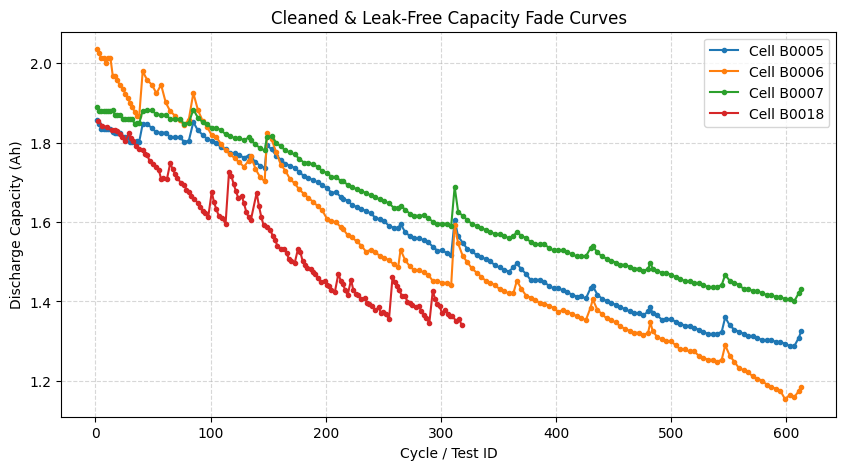

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold


gkf = GroupKFold(n_splits=4)
groups = df_ml['battery_id'].values
X = df_ml[[c for c in df_ml.columns if c.startswith('feat_')]]
y = df_ml['target_capacity'].values

print("4 FOLD GROUP BASED SPLIT (NO DATA LEAKAGE)")
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    val_cells = sorted(list(set(groups[val_idx])))
    print(f"Fold {fold+1} Test Cells: {val_cells} (Samples: {len(val_idx)})")


plt.figure(figsize=(10, 5))
for cell in ['B0005', 'B0006', 'B0007', 'B0018']:
    sub = df_ml[df_ml['battery_id'] == cell]
    plt.plot(sub['test_id'], sub['target_capacity'], marker='.', label=f"Cell {cell}")

plt.xlabel("Cycle / Test ID")
plt.ylabel("Discharge Capacity (Ah)")
plt.title("Cleaned & Leak-Free Capacity Fade Curves")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
